In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import skimage.morphology as mo
from skimage import io, color #Scikit-Image
from PIL import Image # Pillow
import cv2
import os
import random
import torch # Will work on using PyTorch here later
from torch.utils.data  import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
import pandas as pd
from muscle_dataset import Muscle
import re

In [8]:
import torch
print(torch.cuda.is_available())

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")

False
tensor([1.], device='mps:0')


In [9]:
# Init transform functions
tx_X = transforms.Compose([transforms.Resize((256, 256)),
                           transforms.ToTensor(),
                           transforms.Normalize((0.5,), (0.5,))])
tx_Y = transforms.Compose([transforms.Resize((256, 256)),
                           transforms.ToTensor(),  ################ no need to normalize the mask
                           # transforms.Normalize((0.5,), (0.5,))
                          ])
if __name__ == "__main__":
    train_data = Muscle(train=True, transformX=tx_X, transformY=tx_Y)
    train_loader = DataLoader(dataset=train_data, batch_size=8, shuffle=True, num_workers=2)
    validation_data = Muscle(train = False, transformX = tx_X, transformY = tx_Y)

In [10]:
# Dataloaders
batch_size=8
train_loader = DataLoader(dataset = train_data, batch_size = 8, shuffle = True, num_workers = 2)
validation_loader = DataLoader(dataset = validation_data, batch_size = 8, shuffle = True, num_workers = 2)
print(len(train_loader)) #len(train_loader)*batch_size = total number of images in training set (50*8 = 400), hayo: now 30?
print(len(validation_loader)) #len(validation_loader)*batch_size = total number of images in validation set(13*8 = 104 ~ 100)

#hayo the validation_loader is now 8 instead of 13
print(len(validation_loader)*batch_size)

8
2
16


In [11]:
# The following functions will return numpy array from the transformed tensors which were
# obtained from our train_loader. Plot them and see if they are intact
def im_converterX(tensor):
  image = tensor.clone().detach().numpy() # make copy of tensor and converting it to numpy
                                              # as we will need original later
  image = image.transpose(1,2,0) # swapping axes making (1, 28, 28) image to a (28, 28, 1)
  print("image shape is ",image.shape)
  image = image * np.array((0.5, 0.5, 0.5)) + np.array((0.5, 0.5, 0.5)) # unnormalizing the image
                                              # this also outputs (28, 28, 3) which seems important for plt.imshow
  image = image.clip(0, 1) # to make sure final values are in range 0 to 1 as .ToTensor outputed
  return image

def im_converterY(tensor):
  image = tensor.clone().detach().numpy()
  image = image.transpose(1,2,0)
  print("image shape is ",image.shape)
  image = image * np.array((1, 1, 1))
  image = image.clip(0, 1)
  return image

<PIL.Image.Image image mode=L size=360x420 at 0x30166AD90>
<PIL.Image.Image image mode=L size=360x422 at 0x308C94450>
<PIL.Image.Image image mode=L size=360x421 at 0x308CCB390>
<PIL.Image.Image image mode=L size=232x452 at 0x3020C7290>
<PIL.Image.Image image mode=L size=296x454 at 0x308CCB5D0>
<PIL.Image.Image image mode=L size=360x423 at 0x3020C7590>
<PIL.Image.Image image mode=L size=293x454 at 0x308CCB690>
<PIL.Image.Image image mode=L size=360x422 at 0x302077950>
<PIL.Image.Image image mode=L size=359x422 at 0x308CCB850>
<PIL.Image.Image image mode=L size=360x421 at 0x3020C79D0>
<PIL.Image.Image image mode=L size=294x452 at 0x308CCBC50>
<PIL.Image.Image image mode=L size=232x452 at 0x3020C7C90>
<PIL.Image.Image image mode=L size=360x422 at 0x308CCBE10>
<PIL.Image.Image image mode=L size=296x452 at 0x3020C7F10>
<PIL.Image.Image image mode=L size=294x454 at 0x308CCBFD0>
<PIL.Image.Image image mode=L size=296x453 at 0x3020D8190>
0 torch.Size([8, 3, 256, 256]) torch.Size([8, 1, 256, 25

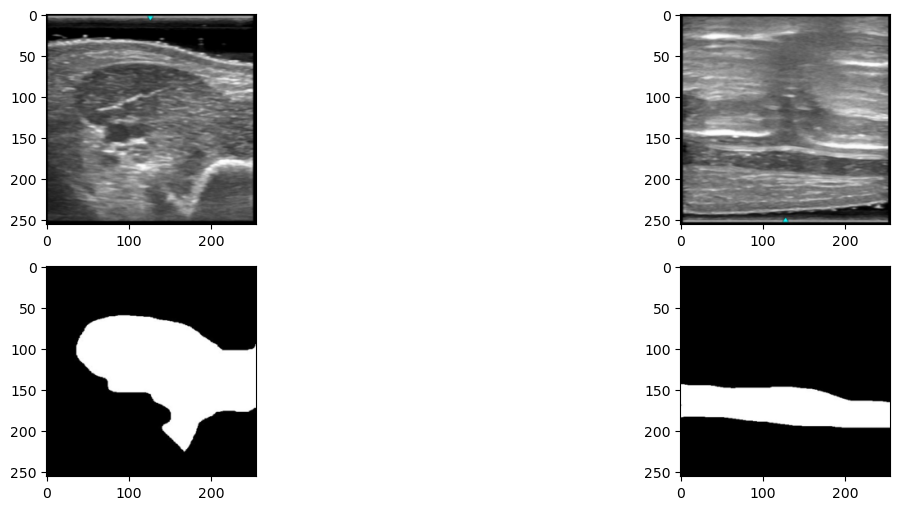

In [12]:
fig = plt.figure(figsize = (15,6))

for ith_batch, sample_batched in enumerate(train_loader):
    print(ith_batch, sample_batched['image'].size(), sample_batched['mask'].size())

    for index in range(2):
        ax = fig.add_subplot(2, 2 , index + 1)  # subplot index starts from 1
        plt.imshow(im_converterX(sample_batched['image'][index]))
        ax = fig.add_subplot(2, 2, index + 3)
        plt.imshow(im_converterY(sample_batched['mask'][index]))
    break

In [13]:
class double_conv(nn.Module):
  '''(conv => BN => ReLU) * 2'''
  def __init__(self, in_ch, out_ch):
    super(double_conv, self).__init__()
    self.conv = nn.Sequential(
      nn.Conv2d(in_ch, out_ch, 3, padding=1),
      nn.BatchNorm2d(out_ch),
      nn.ReLU(inplace=True),
      nn.Conv2d(out_ch, out_ch, 3, padding=1),
      nn.BatchNorm2d(out_ch),
      nn.ReLU(inplace=True)
    )

  def forward(self, x):
    x = self.conv(x)
    return x

class inconv(nn.Module):
  def __init__(self, in_ch, out_ch):
    super(inconv, self).__init__()
    self.conv = double_conv(in_ch, out_ch)

  def forward(self, x):
    x = self.conv(x)
    return x

class down(nn.Module):
  def __init__(self, in_ch, out_ch):
    super(down, self).__init__()
    self.mpconv = nn.Sequential(
        nn.MaxPool2d(2),
        double_conv(in_ch, out_ch)
    )

  def forward(self, x):
    x = self.mpconv(x)
    return x


class up(nn.Module):
  def __init__(self, in_ch, out_ch, bilinear=True):
    super(up, self).__init__()
    self.up = nn.Upsample(
      scale_factor=2, mode='bilinear', align_corners=True)
    self.up = nn.ConvTranspose2d(in_ch // 2, in_ch // 2, kernel_size=2, stride=2)
    self.conv = double_conv(in_ch, out_ch)

  def forward(self, x1, x2):
    x1 = self.up(x1)
    diff1 = x2.shape[2]-x1.shape[2]
    diff2 = x2.shape[3]-x1.shape[3]
    x1 = F.pad(x1, pad=(diff1//2, diff1-diff1//2, diff2//2, diff2-diff2//2))
    x = torch.cat([x2, x1], dim=1)
    x = self.conv(x)
    return x


class outconv(nn.Module):
  def __init__(self, in_ch, out_ch):
    super(outconv, self).__init__()
    self.conv = nn.Conv2d(in_ch, out_ch, 1)

  def forward(self, x):
    x = self.conv(x)
    return x

In [14]:
class UNet(nn.Module):
  def __init__(self, n_channels, n_classes):
    super(UNet, self).__init__()
    self.inc = inconv(n_channels, 64)
    self.down1 = down(64, 128)
    self.down2 = down(128, 256)
    self.down3 = down(256, 512)
    self.down4 = down(512, 512)
    self.up1 = up(1024, 256, bilinear = False)
    self.up2 = up(512, 128, bilinear = False)
    self.up3 = up(256, 64, bilinear = False)
    self.up4 = up(128, 64, bilinear = False)
    self.outc = outconv(64, n_classes)
    self.dropout = torch.nn.Dropout2d(0.5)

  def forward(self, x):
    x = x.float()
    x1 = self.inc(x)
    x2 = self.down1(x1)
    x3 = self.down2(x2)
    x4 = self.down3(x3)
    x5 = self.down4(x4)
    x = self.up1(x5, x4)
    x = self.up2(x, x3)
    x = self.dropout(x)
    x = self.up3(x, x2)
    x = self.up4(x, x1)
    x = self.outc(x)
    return torch.sigmoid(x)

In [15]:
model = UNet(3, 1)
# hayo: had to edit model.to('cuda') bc Apple hasn't supported NVIDIA graphics cards 
# natively in macOS since macOS Mojave
model.to(mps_device)
print("Model Loaded to GPU")

Model Loaded to GPU


In [16]:
criterion = nn.BCELoss() # BCE = Binary Cross Entropy
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01) # lr = learning rate

In [17]:
# calculates similarity index between predicted and actual segmentation
def dice_index(y_pred, y_actual):
  smooth = 0.000001 # prevent division by 0
  size_of_batch = y_pred.size(0)

  p1 = y_pred.view(size_of_batch, -1)
  p2 = y_actual.view(size_of_batch, -1)

  intersection = (p1 * p2).sum()

  dice =  ((2.0 * intersection )+ smooth) / (p1.sum() + p2.sum() + smooth)
  #dice.requires_grad = True

  return dice

# calculate dice loss which will be later used in loss function calculation
def dice_loss(y_predict, y_train): ## to add in bce looss
  return 1 -(dice_index(y_predict, y_train))

In [18]:
epochs = 40 # number of iterations of the training dataset during the training process

train_running_loss_history = []
validation_running_loss_history = []

model.to(mps_device)

for e in range(epochs):
  train_running_loss = 0.0
  validation_running_loss = 0.0
  model.train()
  for ith_batch, sample_batched in enumerate(train_loader):
    X_train = sample_batched['image'].to('mps')
    y_train = sample_batched['mask'].to('mps') # hayo: used mps instead of cuda 
    optimizer.zero_grad()
    y_pred = model(X_train) # hayo: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same
    loss = 0.30 * dice_loss(y_pred, y_train) +  0.70 * criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    if ith_batch % 5 == 0:
      print('Epoch: ', e + 1, 'Batch: ', ith_batch, 'Current Loss: ', loss.item())
    train_running_loss += loss.item()
  else:
    with torch.no_grad():
      model.eval()
      for ith_batch, sample_batched in enumerate(validation_loader):
        X_val = sample_batched['image'].to('mps')
        y_val = sample_batched['mask'].to('mps')
        y_out = model(X_val)
        out_val = (y_out + 0.5).int().float()
        val_loss = 0.3 * dice_loss(out_val, y_val)  + 0.7 * criterion(y_out, y_val)
        validation_running_loss += val_loss.item()
      print("================================================================================")
      print("Epoch {} completed".format(e + 1))

      train_epoch_loss = train_running_loss / len(train_loader)
      validation_epoch_loss = validation_running_loss / len(validation_loader)

      print("Average train loss is {}: ".format(train_epoch_loss))
      print("Average validation loss is {}".format(validation_epoch_loss))
      print("================================================================================")
      train_running_loss_history.append(train_epoch_loss)
      validation_running_loss_history.append(validation_epoch_loss)

# No need to clear since we switched from cuda to cpu 
# Cpu so slow i lost my patience, switched to mps on pytorch 
  # torch.cpu.empty_cache()

<PIL.Image.Image image mode=L size=295x452 at 0x17797C590>
<PIL.Image.Image image mode=L size=232x452 at 0x177E94350>
<PIL.Image.Image image mode=L size=359x423 at 0x1779C7250>
<PIL.Image.Image image mode=L size=357x422 at 0x177ECF210>
<PIL.Image.Image image mode=L size=295x454 at 0x1779C7510>
<PIL.Image.Image image mode=L size=296x452 at 0x177ECF490>
<PIL.Image.Image image mode=L size=360x422 at 0x1779C7750>
<PIL.Image.Image image mode=L size=294x452 at 0x177ECF6D0>
<PIL.Image.Image image mode=L size=360x421 at 0x1779C79D0>
<PIL.Image.Image image mode=L size=296x452 at 0x177ECF950>
<PIL.Image.Image image mode=L size=296x454 at 0x1779C7C90>
<PIL.Image.Image image mode=L size=359x422 at 0x177ECFC50>
<PIL.Image.Image image mode=L size=360x421 at 0x1779C7F50>
<PIL.Image.Image image mode=L size=360x422 at 0x177ECFF10>
<PIL.Image.Image image mode=L size=232x452 at 0x1779D8210>
<PIL.Image.Image image mode=L size=296x453 at 0x177ED81D0>
<PIL.Image.Image image mode=L size=232x452 at 0x1779D881

KeyboardInterrupt: 

In [ ]:
plt.plot(train_running_loss_history, label = 'Train Loss')
plt.plot(validation_running_loss_history, label = 'Validation Loss')
plt.legend()

In [ ]:
model.eval()

In [ ]:
def avg_dice_index(dataloader):
    dice = 0.0
    model.eval()
    with torch.no_grad():
        for ith_batch, sample_batched in enumerate(dataloader):
            X_train = sample_batched['image'].to('mps')
            y_train = sample_batched['mask'].to('mps')
            y_predict = (model(X_train) + 0.5).int().float()
            dice += dice_index(y_predict, y_train)
    avg_dice = dice / len(dataloader)
    return avg_dice.item()

In [ ]:
avg_dice_index(validation_loader)

In [ ]:

avg_dice_index(train_loader)

In [ ]:
torch.save(model, os.path.join('/Users/taliacho/Downloads/Ranger/Bryan-Ranger/local_data', 'Learn_Unet.pt'))
model = torch.load(os.path.join('/Users/taliacho/Downloads/Ranger/Bryan-Ranger/local_data', 'Learn_Unet.pt'))
model.to('mps')
model.eval()

In [ ]:
class Muscle_test(Dataset):
    def __init__(self, transformX = None):
        self.pixel_file = pd.read_csv(os.path.join('../local_data/IUS_test.csv'))
        self.transformX = transformX

    def __len__(self):
        return len(self.pixel_file)

    def __getitem__(self, index):
        imx_name = os.path.join('../local_data/train_data-2', self.pixel_file.iloc[index, 1])

        imx = Image.open(imx_name)

        f_name = self.pixel_file.iloc[index, 1]

        if self.transformX :
            imx = self.transformX(imx)

        sample = {'image': imx, 'f_name': f_name}
        return sample

tx_X = transforms.Compose([transforms.Resize((256, 256)),
                           transforms.ToTensor(),
                           transforms.Normalize((0.5,), (0.5,))])
test_data = Muscle_test(transformX = tx_X)
test_loader = DataLoader(dataset = test_data, batch_size = 1, shuffle = True)

In [ ]:
def im_converterX(tensor):
  image = tensor.clone().cpu().detach().numpy() # make copy of tensor and converting it to numpy
                                              # as we will need original later
  image = image.transpose(1,2,0) # swapping axes making (1, 28, 28) image to a (28, 28, 1)
  # print(image.shape)
  image = image * np.array((0.5, 0.5, 0.5)) + np.array((0.5, 0.5, 0.5)) # unnormalizing the image
                                              # this also outputs (28, 28, 3) which seems important for plt.imshow
  image = image.clip(0, 1) # to make sure final values are in range 0 to 1 
  return image

def im_converterY(tensor):
  image = tensor.cpu().clone().detach().numpy()
  image = image.transpose(1,2,0)
  # print(image.shape)
  image = image * np.array((1, 1, 1))
  image = image.clip(0, 1)
  return image

In [ ]:
fig = plt.figure(figsize = (20,8))
for index in range(5):
  for ith_batch, sample_batched in enumerate(test_loader):
    X_test = sample_batched['image'].to('mps')
    y_test = (model(X_test)+0.5).int().float()
  ax = fig.add_subplot(2, 5 , index + 1)  # subplot index starts from 1
  plt.imshow(im_converterX(X_test[0]))

  ax  = fig.add_subplot(2, 5, index + 6)
  plt.imshow(im_converterY(y_test[0]))